# El comercio de fauna silvestre y los patógenos que compartimos

**1 de cada 3 mamíferos silvestres del planeta ha pasado por alguna forma de comercio.** ¿Cuántos de esos animales comparten enfermedades con nosotros?

---

📄 **Paper:** Gippet et al. (2026). *Wildlife trade drives animal-to-human pathogen transmission over 40 years*. **Science**.
DOI: [10.1126/science.adw5518](https://doi.org/10.1126/science.adw5518)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-11-comercio-fauna-patogenos-zoonoticos/notebook.ipynb)

## El problema

Cada vez que un animal silvestre entra en una cadena de comercio — legal o ilegal, vivo o como producto — se crea una oportunidad para que sus patógenos salten a humanos. Lo sabíamos en general, pero nadie había cuantificado el efecto a escala global.

Cruzaron 40 años de datos de comercio internacional (CITES, LEMIS) con registros de patógenos compartidos — **6.456 especies de mamíferos silvestres** en total. ¿El resultado? Las especies comerciadas tienen **1,5 veces más probabilidad** de compartir patógenos con nosotros — y eso es *después* de controlar por parentesco evolutivo y esfuerzo de investigación.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FOLD_PAPER = 1.5             # Factor ajustado (GLMM) del paper
N_ESPECIES = 6456            # Mamíferos silvestres extantes (sin domésticos ni extintos)
FUENTE = 'Fuente: Gippet et al. (2026), Science | Datos: GitHub/JGippet'
COLOR_TRADED = '#DC2626'     # Rojo — comerciadas
COLOR_NOT_TRADED = '#2563EB' # Azul — no comerciadas
COLOR_ILLEGAL = '#7C3AED'   # Violeta — ilegal
COLOR_LEGAL = '#059669'     # Emerald — solo legal
COLOR_REF = '#D97706'       # Amber — referencia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/mamiferos_comercio_patogenos.csv')

# Filtrar: extantes y no domésticos
df = df[(df['extinct'] == 0) & (df['DOMESTICATED_large'] == 'no')].copy()

# Variables clave
df['is_traded'] = df['Traded_all'] == 'yes'
df['is_zoonotic'] = df['Zoonose_vector_1'] == 'Zoonotic'
df['is_illegal'] = df['Traded_illegal'] == 'yes'
df['is_live'] = df['Traded_all_live'] == 'yes'
df['n_pathogens'] = df['ZOONOTIC_NB_all'].fillna(0).astype(int)
df['time_traded'] = df['timeTraded_all_1980_2019'].fillna(0).astype(int)

print(f"Especies cargadas: {len(df):,}")
print(f"Comerciadas: {df['is_traded'].sum():,} ({df['is_traded'].mean()*100:.1f}%)")
print(f"Zoonóticas (≥1 patógeno): {df['is_zoonotic'].sum():,} ({df['is_zoonotic'].mean()*100:.1f}%)")
print(f"Comercio ilegal: {df['is_illegal'].sum():,}")
traded = df[df['is_traded']]
not_traded = df[~df['is_traded']]
prop_t = traded['is_zoonotic'].mean()
prop_nt = not_traded['is_zoonotic'].mean()
print(f"\nCompartición de patógenos:")
print(f"  Comerciadas → zoonóticas: {prop_t*100:.1f}%")
print(f"  No comerciadas → zoonóticas: {prop_nt*100:.1f}%")
print(f"  Fold crudo: {prop_t/prop_nt:.1f}x (el paper reporta {FOLD_PAPER}x ajustado por confounders)")

Especies cargadas: 6,456
Comerciadas: 2,079 (32.2%)
Zoonóticas (≥1 patógeno): 1,136 (17.6%)
Comercio ilegal: 521

Compartición de patógenos:
  Comerciadas → zoonóticas: 41.1%
  No comerciadas → zoonóticas: 6.4%
  Fold crudo: 6.4x (el paper reporta 1.5x ajustado por confounders)


## ¿Qué órdenes de mamíferos se comercian más — y cuáles comparten más patógenos?

Veamos los órdenes con al menos 10 especies comerciadas.

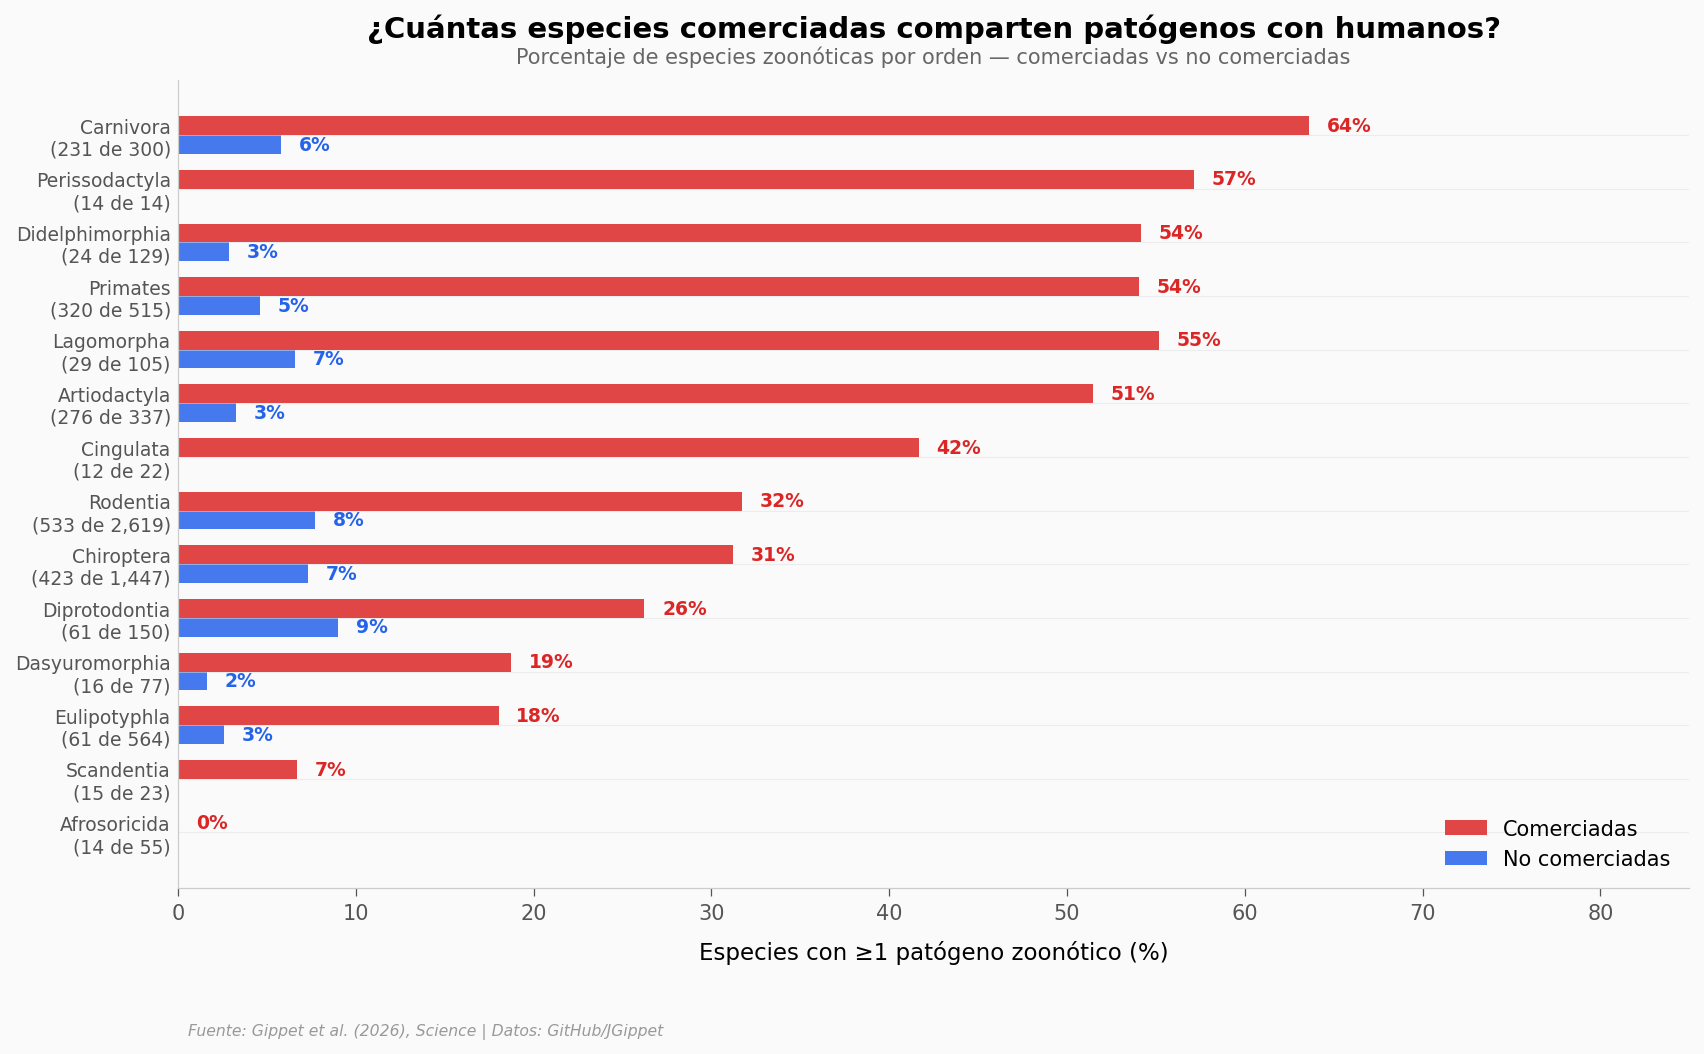

In [2]:
# ── Gráfica hero: comercio y zoonosis por orden ──
order_stats = []
for order_name, group in df.groupby('order'):
    n_total = len(group)
    n_traded_o = group['is_traded'].sum()
    if n_traded_o < 10:
        continue
    traded_g = group[group['is_traded']]
    not_traded_g = group[~group['is_traded']]
    pct_traded_zoo = traded_g['is_zoonotic'].mean() * 100 if len(traded_g) > 0 else 0
    pct_not_traded_zoo = not_traded_g['is_zoonotic'].mean() * 100 if len(not_traded_g) > 0 else 0
    order_stats.append({
        'order': order_name.capitalize(),
        'n_total': n_total,
        'n_traded': int(n_traded_o),
        'pct_traded_zoo': pct_traded_zoo,
        'pct_not_traded_zoo': pct_not_traded_zoo,
        'diff': pct_traded_zoo - pct_not_traded_zoo
    })

order_df = pd.DataFrame(order_stats).sort_values('diff', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

y_pos = np.arange(len(order_df))
bar_h = 0.35

bars_t = ax.barh(y_pos + bar_h/2, order_df['pct_traded_zoo'], bar_h,
                  color=COLOR_TRADED, alpha=0.85, label='Comerciadas')
bars_nt = ax.barh(y_pos - bar_h/2, order_df['pct_not_traded_zoo'], bar_h,
                   color=COLOR_NOT_TRADED, alpha=0.85, label='No comerciadas')

# Inline labels con n
for i, (_, row) in enumerate(order_df.iterrows()):
    ax.text(row['pct_traded_zoo'] + 1, i + bar_h/2,
            f"{row['pct_traded_zoo']:.0f}%", fontsize=9, color=COLOR_TRADED,
            va='center', fontweight='bold')
    if row['pct_not_traded_zoo'] > 0:
        ax.text(row['pct_not_traded_zoo'] + 1, i - bar_h/2,
                f"{row['pct_not_traded_zoo']:.0f}%", fontsize=9, color=COLOR_NOT_TRADED,
                va='center', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['order']}\n({row['n_traded']:,} de {row['n_total']:,})" 
                     for _, row in order_df.iterrows()], fontsize=9)
ax.set_xlabel('Especies con ≥1 patógeno zoonótico (%)', fontsize=11)
ax.set_title('¿Cuántas especies comerciadas comparten patógenos con humanos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de especies zoonóticas por orden — comerciadas vs no comerciadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.set_xlim(0, 85)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_ordenes_comercio.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que salta a la vista

En **casi todos** los órdenes (13 de 14 con n ≥ 10 comerciadas), las especies comerciadas comparten más patógenos con humanos que las no comerciadas. Pero la magnitud varía enormemente.

Los **carnívoros** muestran la brecha más grande: el 63,6% de las especies comerciadas son zoonóticas, contra solo un 5,8% de las no comerciadas. Los **primates** — nuestros parientes más cercanos — tienen el segundo mayor porcentaje de zoonóticas entre las comerciadas (54,1%).

⚠️ **Ojo con la trampa:** este patrón crudo (6,4x en promedio) sobreestima el efecto real. Las especies comerciadas también tienden a ser más estudiadas. Cuando el paper controla por esfuerzo de investigación, filogenia y otros factores, el efecto baja a **1,5x** — todavía significativo (p < 0,001 en el GLMM del paper). El Cohen's d = 0,59 corresponde a la comparación cruda de patógenos (no al fold ajustado).

## El comercio ilegal: un multiplicador de riesgo

No todo comercio es igual. Pero no todo comercio es igual — el tráfico ilegal y el comercio de animales vivos disparan el riesgo. Veamos qué dicen los datos.

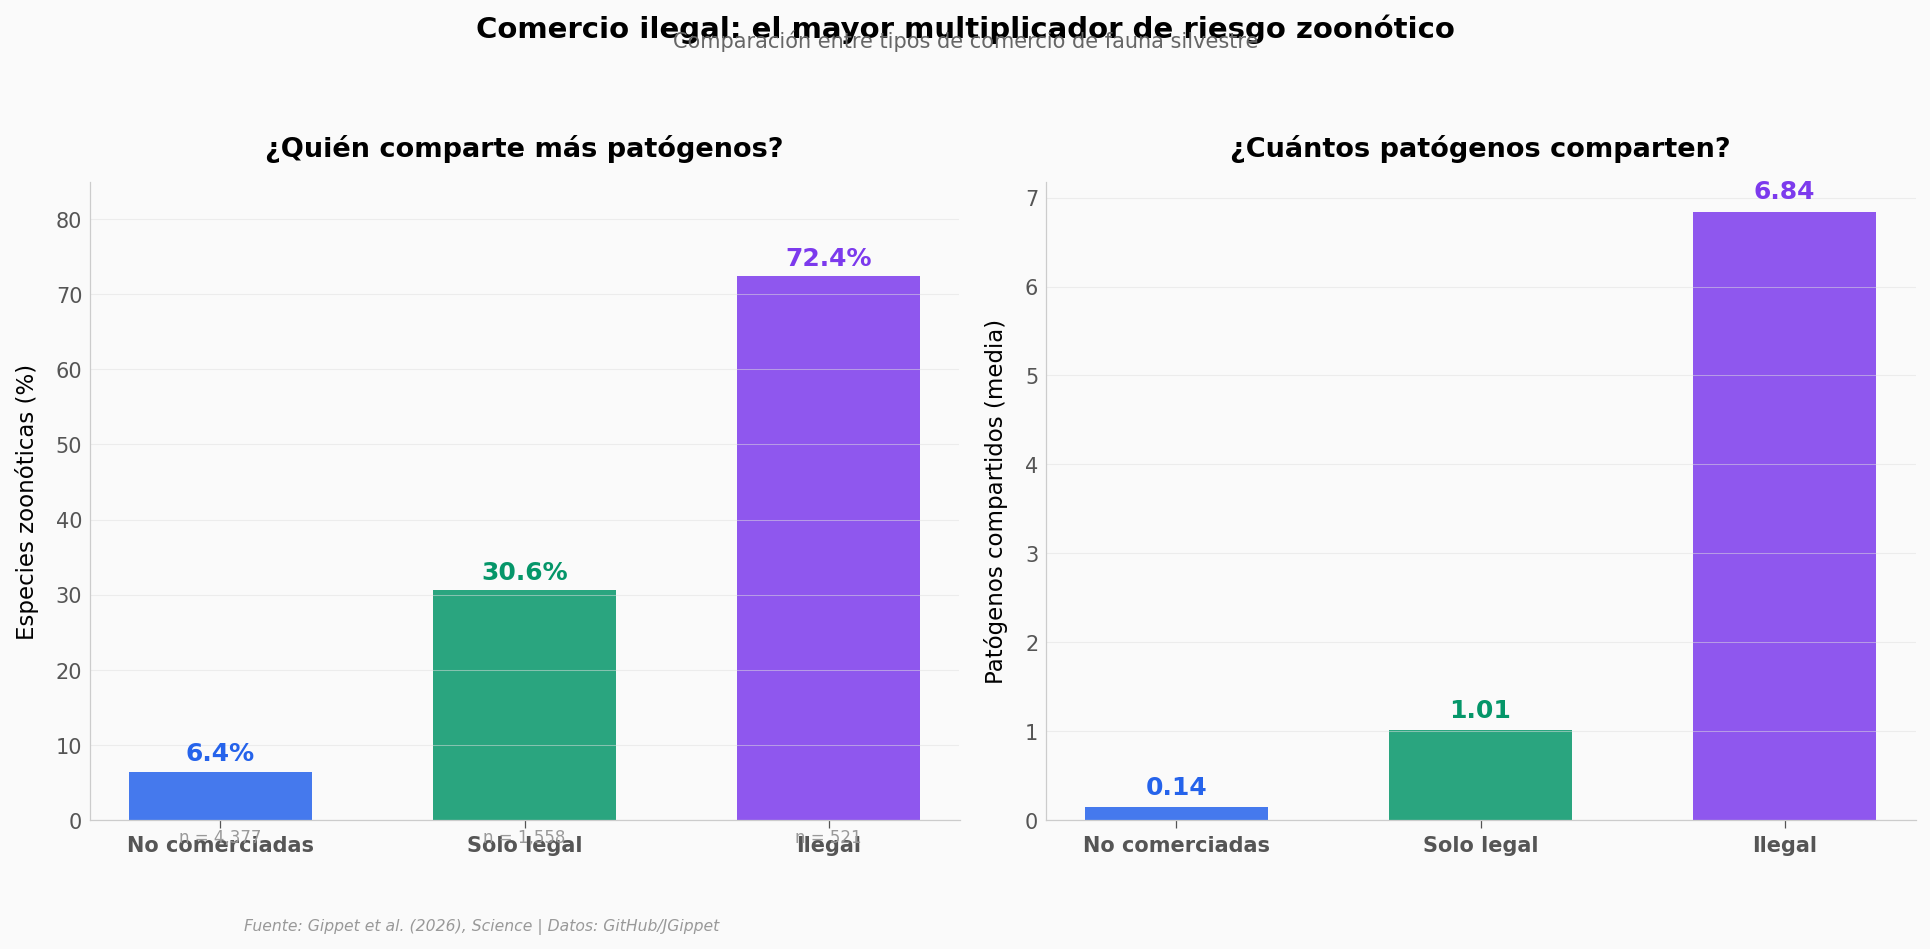

In [3]:
# ── Comparación: ilegal vs solo legal vs no comerciadas ──
df['trade_category'] = 'No comerciadas'
df.loc[df['is_traded'] & ~df['is_illegal'], 'trade_category'] = 'Solo legal'
df.loc[df['is_illegal'], 'trade_category'] = 'Ilegal'

categories = ['No comerciadas', 'Solo legal', 'Ilegal']
colors = [COLOR_NOT_TRADED, COLOR_LEGAL, COLOR_ILLEGAL]
cat_data = []
for cat in categories:
    sub = df[df['trade_category'] == cat]
    cat_data.append({
        'category': cat,
        'n': len(sub),
        'pct_zoo': sub['is_zoonotic'].mean() * 100,
        'mean_pathogens': sub['n_pathogens'].mean(),
        'median_pathogens': sub['n_pathogens'].median()
    })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: % zoonóticas
bars = ax1.bar(range(3), [d['pct_zoo'] for d in cat_data], color=colors, alpha=0.85, width=0.6)
for i, d in enumerate(cat_data):
    ax1.text(i, d['pct_zoo'] + 1.5, f"{d['pct_zoo']:.1f}%",
             ha='center', fontsize=12, fontweight='bold', color=colors[i])
    ax1.text(i, -3, f"n = {d['n']:,}", ha='center', fontsize=8, color='#999999')
ax1.set_xticks(range(3))
ax1.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax1.set_ylabel('Especies zoonóticas (%)', fontsize=11)
ax1.set_ylim(0, 85)
ax1.set_title('¿Quién comparte más patógenos?', fontsize=13, fontweight='bold', pad=12)

# Panel derecho: media de patógenos
bars2 = ax2.bar(range(3), [d['mean_pathogens'] for d in cat_data], color=colors, alpha=0.85, width=0.6)
for i, d in enumerate(cat_data):
    ax2.text(i, d['mean_pathogens'] + 0.15, f"{d['mean_pathogens']:.2f}",
             ha='center', fontsize=12, fontweight='bold', color=colors[i])
ax2.set_xticks(range(3))
ax2.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax2.set_ylabel('Patógenos compartidos (media)', fontsize=11)
ax2.set_title('¿Cuántos patógenos comparten?', fontsize=13, fontweight='bold', pad=12)

fig.suptitle('Comercio ilegal: el mayor multiplicador de riesgo zoonótico',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Comparación entre tipos de comercio de fauna silvestre',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/ilegal_vs_legal.png', dpi=200, bbox_inches='tight')
plt.show()

### El salto del ilegal

El 72,4% de las especies comerciadas ilegalmente comparten al menos un patógeno con humanos — más del doble que las comerciadas solo legalmente (30,6%). La diferencia es grande (Cohen's h = 0,86, n ilegal = 521, n solo legal = 1.558). Y la media de patógenos se dispara: **6,84** por especie ilegal vs **1,01** por especie solo legal (Cohen's d = 0,93, efecto grande).

¿Por qué? Todo apunta a los sospechosos habituales: el comercio ilegal evade controles sanitarios, mueve animales vivos en condiciones de estrés y hacinamiento, y mezcla especies que nunca compartirían espacio en la naturaleza.

## Más tiempo en comercio → más patógenos

Por cada **10 años** que una especie lleva en el comercio, comparte en promedio **un patógeno adicional** con humanos. Veamos si los datos lo confirman.

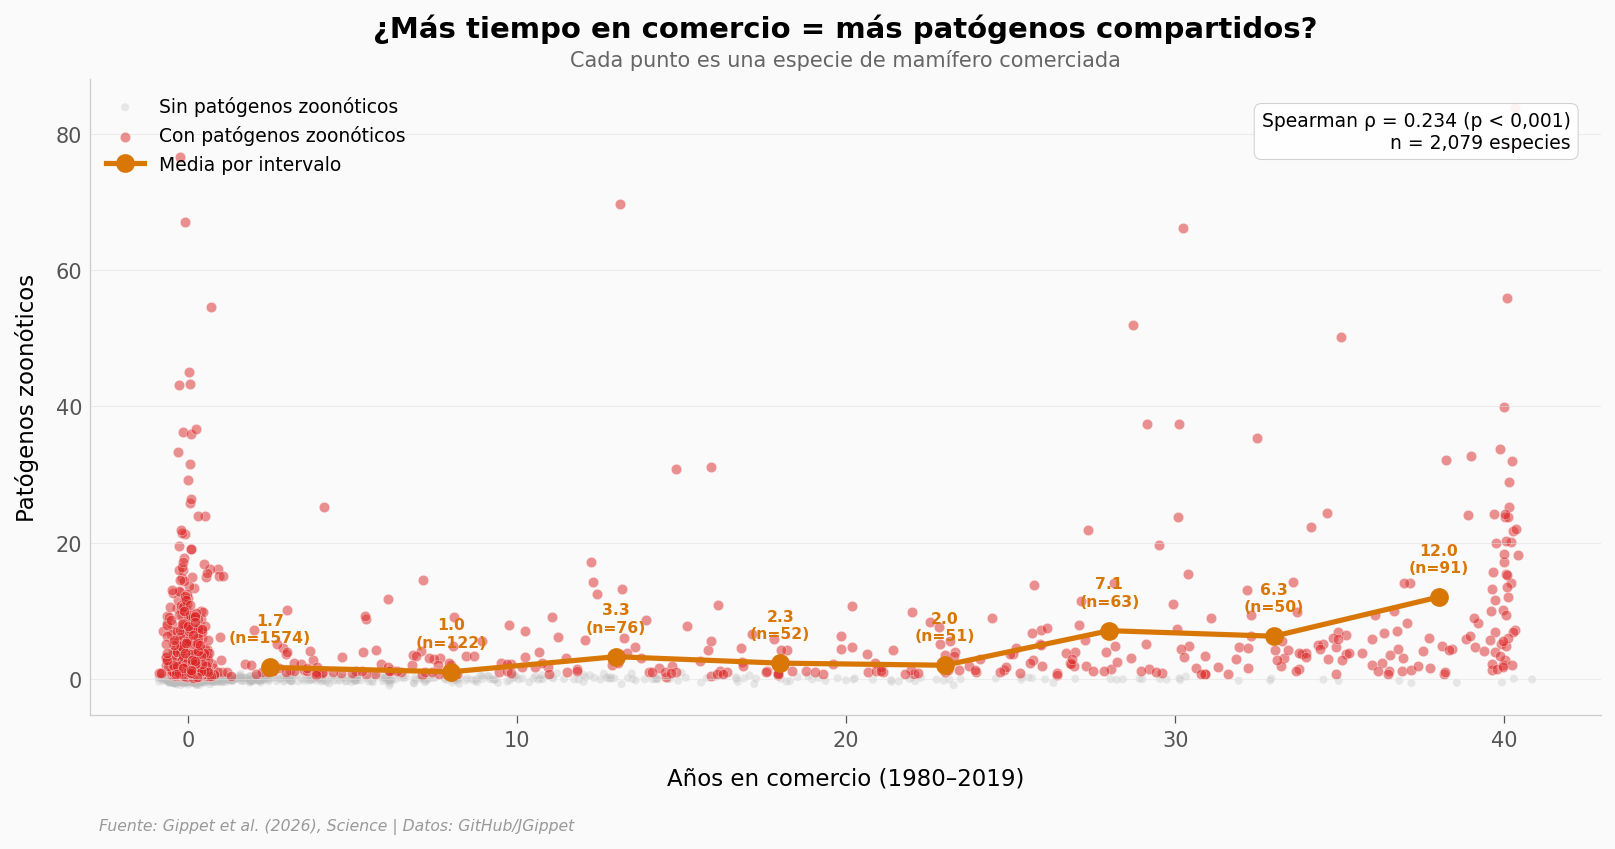

In [4]:
# ── Tiempo en comercio vs número de patógenos ──
traded_df = df[df['is_traded']].copy()

fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)
jitter_y = traded_df['n_pathogens'] + np.random.normal(0, 0.3, len(traded_df))
jitter_x = traded_df['time_traded'] + np.random.normal(0, 0.3, len(traded_df))

# Color by whether zoonotic
colors_scatter = [COLOR_TRADED if z else '#BBBBBB' for z in traded_df['is_zoonotic']]
ax.scatter(jitter_x[~traded_df['is_zoonotic']], jitter_y[~traded_df['is_zoonotic']],
           c='#BBBBBB', s=15, alpha=0.3, edgecolors='none', label='Sin patógenos zoonóticos')
ax.scatter(jitter_x[traded_df['is_zoonotic']], jitter_y[traded_df['is_zoonotic']],
           c=COLOR_TRADED, s=25, alpha=0.5, edgecolors='white', linewidths=0.3,
           label='Con patógenos zoonóticos')

# Binned means
bins = [(0, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30), (31, 35), (36, 40)]
bin_x, bin_y, bin_n = [], [], []
for lo, hi in bins:
    mask = (traded_df['time_traded'] >= lo) & (traded_df['time_traded'] <= hi)
    if mask.sum() >= 5:
        bin_x.append((lo + hi) / 2)
        bin_y.append(traded_df.loc[mask, 'n_pathogens'].mean())
        bin_n.append(mask.sum())

ax.plot(bin_x, bin_y, 'o-', color=COLOR_REF, linewidth=2.5, markersize=8,
        zorder=10, label='Media por intervalo')

# Annotate key points
for x, y, n in zip(bin_x, bin_y, bin_n):
    ax.annotate(f'{y:.1f}\n(n={n})', xy=(x, y), xytext=(0, 12),
                textcoords='offset points', fontsize=7.5, color=COLOR_REF,
                ha='center', fontweight='bold')

# Spearman
rho, p = stats.spearmanr(traded_df['time_traded'], traded_df['n_pathogens'])
ax.text(0.98, 0.95, f'Spearman ρ = {rho:.3f} (p < 0,001)\nn = {len(traded_df):,} especies',
        transform=ax.transAxes, fontsize=9, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

ax.set_xlabel('Años en comercio (1980–2019)', fontsize=11)
ax.set_ylabel('Patógenos zoonóticos', fontsize=11)
ax.set_title('¿Más tiempo en comercio = más patógenos compartidos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto es una especie de mamífero comerciada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tiempo_comercio_patogenos.png', dpi=200, bbox_inches='tight')
plt.show()

### El patrón temporal

Las especies con 0-5 años en comercio comparten en promedio **1,7 patógenos**. Las que llevan 26-40 años: **9,1**. La correlación es modesta (ρ = 0,234, p < 0,001, n = 2.079), lo cual tiene sentido — el número de patógenos depende de muchos factores además del tiempo en comercio. Pero la tendencia es clara y estadísticamente robusta.

El chimpancé (*Pan troglodytes*) y el macaco rhesus (*Macaca mulatta*), ambos con 40 años en comercio, lideran con 84 y 78 patógenos compartidos con humanos respectivamente.

## ¿Qué tan diferente es una especie comerciada?

Veamos la distribución completa del número de patógenos: comerciadas vs no comerciadas.

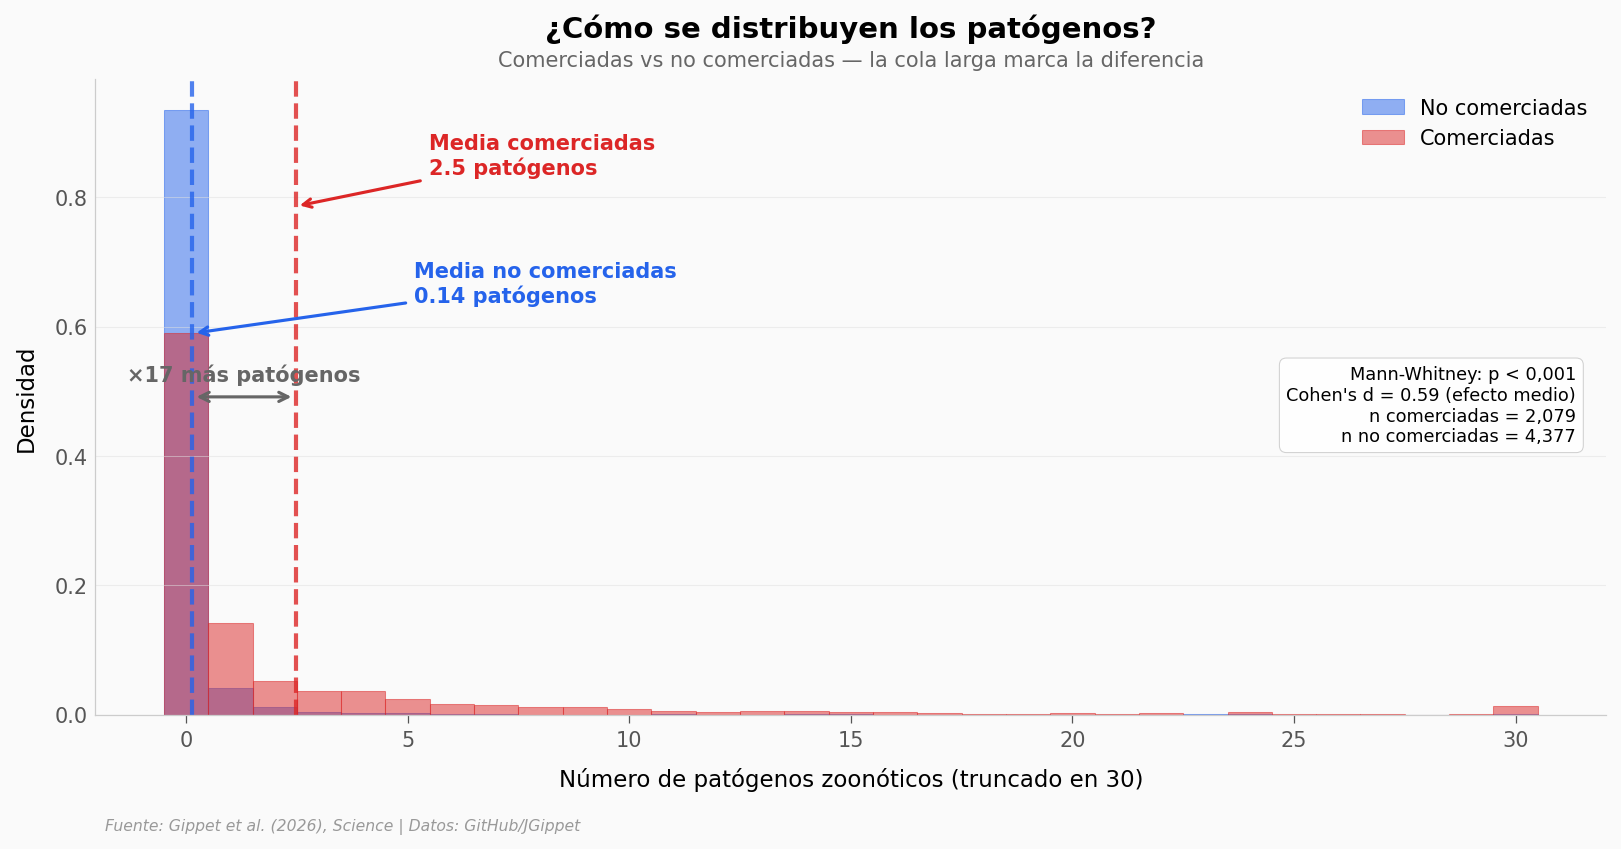

In [5]:
# ── Histograma: distribución de patógenos ──
fig, ax = plt.subplots(figsize=(13, 5.5))

max_val = 30  # Truncar para legibilidad (hay outliers hasta 84)
traded_vals = traded['n_pathogens'].clip(upper=max_val)
not_traded_vals = not_traded['n_pathogens'].clip(upper=max_val)

bins_h = np.arange(-0.5, max_val + 1.5, 1)
ax.hist(not_traded_vals, bins=bins_h, color=COLOR_NOT_TRADED, alpha=0.5,
        edgecolor=COLOR_NOT_TRADED, linewidth=0.5, label='No comerciadas', density=True)
ax.hist(traded_vals, bins=bins_h, color=COLOR_TRADED, alpha=0.5,
        edgecolor=COLOR_TRADED, linewidth=0.5, label='Comerciadas', density=True)

# Medias
mean_t = traded['n_pathogens'].mean()
mean_nt = not_traded['n_pathogens'].mean()
ax.axvline(mean_t, color=COLOR_TRADED, linewidth=2, linestyle='--', alpha=0.8)
ax.axvline(mean_nt, color=COLOR_NOT_TRADED, linewidth=2, linestyle='--', alpha=0.8)

ax.annotate(f'Media comerciadas\n{mean_t:.1f} patógenos', xy=(mean_t, ax.get_ylim()[1]*0.8),
            xytext=(mean_t + 3, ax.get_ylim()[1]*0.85),
            fontsize=10, color=COLOR_TRADED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_TRADED, lw=1.5))
ax.annotate(f'Media no comerciadas\n{mean_nt:.2f} patógenos', xy=(mean_nt, ax.get_ylim()[1]*0.6),
            xytext=(mean_nt + 5, ax.get_ylim()[1]*0.65),
            fontsize=10, color=COLOR_NOT_TRADED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_NOT_TRADED, lw=1.5))

# Bidirectional arrow
y_arrow = ax.get_ylim()[1] * 0.5
ax.annotate('', xy=(mean_t, y_arrow), xytext=(mean_nt, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
mid = (mean_t + mean_nt) / 2
ax.text(mid, y_arrow * 1.05, f'×{mean_t/mean_nt:.0f} más patógenos',
        ha='center', fontsize=10, color='#666666', fontweight='bold')

ax.set_xlabel('Número de patógenos zoonóticos (truncado en 30)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('¿Cómo se distribuyen los patógenos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Comerciadas vs no comerciadas — la cola larga marca la diferencia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

# Stats box
u_stat, u_p = stats.mannwhitneyu(traded['n_pathogens'], not_traded['n_pathogens'])
pooled_std = np.sqrt(((len(traded)-1)*traded['n_pathogens'].std(ddof=1)**2 +
                       (len(not_traded)-1)*not_traded['n_pathogens'].std(ddof=1)**2) /
                      (len(traded)+len(not_traded)-2))
d = abs(mean_t - mean_nt) / pooled_std
ax.text(0.98, 0.55, f"Mann-Whitney: p < 0,001\nCohen's d = {d:.2f} (efecto medio)\n"
        f"n comerciadas = {len(traded):,}\nn no comerciadas = {len(not_traded):,}",
        transform=ax.transAxes, fontsize=8.5, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_patogenos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las comerciadas son 1,5x más propensas a compartir patógenos | ⚠️ Parcial | Nuestros datos crudos muestran 6,4x (41,1% vs 6,4%). El 1,5x del paper es el efecto *ajustado* por GLMMs controlando filogenia y esfuerzo de investigación — no lo podemos replicar sin el modelo completo |
| Comercio ilegal exacerba la compartición | ✅ | 72,4% de ilegales son zoonóticas vs 30,6% de solo legales — 2,4x más (Cohen's h = 0,86, n = 521 vs 1.558) |
| +1 patógeno por cada 10 años en comercio | ⚠️ Parcial | Los datos muestran la tendencia (1,7 → 9,1 patógenos de 0-5 a 26-40 años), pero ρ = 0,234 indica una correlación modesta. El claim del paper proviene del modelo ajustado |
| Comercio de animales vivos exacerba transmisión | ⚠️ Parcial | Las especies comerciadas como vivos Y productos: 70,6% zoonóticas. Solo vivos: 28,0% (n = 25, muestra muy chica). El efecto aparece en la combinación, no en "solo vivos" |

> **Limitaciones:**
> - No podemos replicar los GLMMs del paper (requieren filogenia y eigenvectores filogenéticos). Los datos crudos sobreestiman el efecto porque no separan cuánto se estudia cada especie ni cuán emparentada está con nosotros
> - El diseño es **observacional**: correlación ≠ causalidad. Que las especies comerciadas compartan más patógenos no significa que el comercio *cause* la transmisión — aunque los mecanismos son plausibles
> - La base CLOVER captura patógenos *conocidos*. Las especies más estudiadas tienen más patógenos registrados por definición
> - Los datos de comercio ilegal provienen de incautaciones — subestiman el comercio real

## Ahora tú

1. **¿Qué orden tiene la mayor brecha?** Filtra `df` por un orden específico y compara la media de patógenos entre comerciadas y no comerciadas. ¿Los murciélagos (*Chiroptera*) son tan problemáticos como se piensa?

2. **¿El parentesco importa?** La columna `PhyloDist_Homosapiens_mean` mide la distancia filogenética a humanos. ¿Las especies más cercanas a nosotros comparten más patógenos? Prueba `stats.spearmanr(df['PhyloDist_Homosapiens_mean'], df['n_pathogens'])`.

3. **¿Sinantropía o comercio?** Las especies sinantrópicas (que viven cerca de humanos) también comparten más patógenos. ¿Es el comercio o la cercanía? Compara comerciadas sinantrópicas vs comerciadas no sinantrópicas.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Los murciélagos son el mayor riesgo zoonótico?
chiroptera = df[df['order'] == 'CHIROPTERA']
print(f"Murciélagos: {len(chiroptera)} especies")
print(f"  Comerciados: {chiroptera['is_traded'].sum()} ({chiroptera['is_traded'].mean()*100:.1f}%)")

chir_traded = chiroptera[chiroptera['is_traded']]
chir_not = chiroptera[~chiroptera['is_traded']]
print(f"  Comerciados → zoonóticos: {chir_traded['is_zoonotic'].mean()*100:.1f}%")
print(f"  No comerciados → zoonóticos: {chir_not['is_zoonotic'].mean()*100:.1f}%")
print(f"  Media patógenos (comerciados): {chir_traded['n_pathogens'].mean():.2f}")
print(f"  Media patógenos (no comerciados): {chir_not['n_pathogens'].mean():.2f}")

# Compara con primates
primates = df[df['order'] == 'PRIMATES']
pri_traded = primates[primates['is_traded']]
print(f"\nPrimates comerciados → zoonóticos: {pri_traded['is_zoonotic'].mean()*100:.1f}%")
print(f"  Media patógenos: {pri_traded['n_pathogens'].mean():.2f}")
print(f"\n→ ¿Quién es el mayor riesgo real? Prueba con otros órdenes.")

Murciélagos: 1447 especies
  Comerciados: 423 (29.2%)
  Comerciados → zoonóticos: 31.2%
  No comerciados → zoonóticos: 7.3%
  Media patógenos (comerciados): 1.06
  Media patógenos (no comerciados): 0.12

Primates comerciados → zoonóticos: 54.1%
  Media patógenos: 4.12

→ ¿Quién es el mayor riesgo real? Prueba con otros órdenes.


---

## Créditos

- **Paper:** Gippet, J.M.W. et al. (2026). *Wildlife trade drives animal-to-human pathogen transmission over 40 years*. Science. DOI: [10.1126/science.adw5518](https://doi.org/10.1126/science.adw5518)
- **Datos:** [GitHub — JGippet/WildlifeTrade_ZoonoticPathogens](https://github.com/JGippet/WildlifeTrade_ZoonoticPathogens) (CC-BY 4.0)
- **Bases de datos:** CITES, LEMIS, CLOVER, VIRION, MDD (ver repo para citas completas)

Este notebook forma parte de [El Lab de Ciencia a Mordiscos](https://cienciaamordiscos.com) — datos reales, verificables, reproducibles. Visita el [repositorio completo](https://github.com/Ciencia-a-Mordiscos/lab).